In [696]:
# Importing dependencies 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_distances

In [697]:
# Loading the dataset
df = pd.read_csv("D:/Python programming/Projects/Custumer Segmentation/marketing_campaign.csv", sep = "\t")
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Data Preprocessing

In [698]:
# Removing null values and irrelevant columns
cols_to_drop = ['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue']
df.drop(columns=cols_to_drop, inplace=True)
df.dropna(inplace=True)

In [699]:
# 1. Create Age from Year_Birth

df["Age"] = 2024 - df["Year_Birth"]

# 2. Calculate total spending across all products

df["Spent"] = (df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"])
df["Spent"] = np.log1p(df["Spent"])

# 3. Create Living_With feature

df["Living_With"] = df["Marital_Status"].replace({"Married": "Partner","Together": "Partner","Absurd": "Alone","Widow": "Alone",
                                                  "YOLO": "Alone","Divorced": "Alone","Single": "Alone"})

# 4. Calculate total number of children

df["Children"] = df["Kidhome"] + df["Teenhome"]

# 5. Calculate total family size

df["Family_Size"] = (df["Living_With"].replace({"Alone": 1,"Partner": 2})+ df["Children"])
df["Family_Size"] = df["Family_Size"].astype('int')

# 6. Create parenthood indicator

df["Is_Parent"] = np.where(df["Children"] > 0, 1, 0)

# 7. Group Education into broader categories

df["Education"] = df["Education"].replace({"Basic": "Undergraduate","2n Cycle": "Undergraduate","Graduation": "Graduate",
                                           "Master": "Postgraduate","PhD": "Postgraduate"})

# 8. Rename product-spending columns for clarity

df = df.rename(columns={"MntWines": "Wines","MntFruits": "Fruits","MntMeatProducts": "Meat","MntFishProducts": "Fish",
                        "MntSweetProducts": "Sweets","MntGoldProds": "Gold"})


# --------------------------------------------------
# 9. Drop redundant/original features
# --------------------------------------------------

to_drop = ["Marital_Status","Year_Birth",'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']

df.drop(columns=to_drop, inplace=True)

## Encoding

In [700]:
le = LabelEncoder()
for col in ['Education', "Living_With"]:
    df[col] = le.fit_transform(df[col])

In [701]:
# Check the final dataset
df.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2216 non-null   int64  
 1   Income               2216 non-null   float64
 2   Kidhome              2216 non-null   int64  
 3   Teenhome             2216 non-null   int64  
 4   Recency              2216 non-null   int64  
 5   Wines                2216 non-null   int64  
 6   Fruits               2216 non-null   int64  
 7   Meat                 2216 non-null   int64  
 8   Fish                 2216 non-null   int64  
 9   Sweets               2216 non-null   int64  
 10  Gold                 2216 non-null   int64  
 11  NumDealsPurchases    2216 non-null   int64  
 12  NumWebPurchases      2216 non-null   int64  
 13  NumCatalogPurchases  2216 non-null   int64  
 14  NumStorePurchases    2216 non-null   int64  
 15  NumWebVisitsMonth    2216 non-null   int64  
 16  Comp

## Scaling

In [702]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled,columns=df.columns,index=df.index)
df_scaled.head()

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,-0.894187,0.234063,-0.823039,-0.928972,0.310532,0.978226,1.549429,1.690227,2.454568,1.484827,...,-0.554143,0.693232,-0.097812,2.377952,0.986443,1.201164,-1.348829,-1.264803,-1.758673,-1.581389
1,-0.894187,-0.234559,1.039938,0.909066,-0.380509,-0.872024,-0.637328,-0.717986,-0.651038,-0.633880,...,-1.169518,-0.131574,-0.097812,-0.420530,1.236801,-1.558354,-1.348829,1.405806,0.450009,0.632356
2,-0.894187,0.769478,-0.823039,-0.928972,-0.795134,0.358511,0.569159,-0.178368,1.340203,-0.146821,...,1.291982,-0.543978,-0.097812,-0.420530,0.318822,0.702211,0.741384,-1.264803,-0.654332,-1.581389
3,-0.894187,-1.017239,1.039938,-0.928972,-0.795134,-0.872024,-0.561922,-0.655551,-0.504892,-0.585174,...,-0.554143,0.280829,-0.097812,-0.420530,-1.266777,-1.111593,0.741384,0.070501,0.450009,0.632356
4,0.569268,0.240221,1.039938,-0.928972,1.554407,-0.391671,0.418348,-0.218505,0.152766,-0.000703,...,0.061232,-0.131574,-0.097812,-0.420530,-1.016420,0.288585,0.741384,0.070501,0.450009,0.632356


## PCA

In [703]:
pca = PCA()
df_pca = pca.fit_transform(df_scaled)

In [704]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([3.36512566e-01, 1.23117405e-01, 6.03659900e-02, 5.36749962e-02,
       4.68097734e-02, 4.40274722e-02, 4.14281735e-02, 3.88165226e-02,
       3.65503460e-02, 3.22637505e-02, 2.62966889e-02, 2.58475479e-02,
       2.10177445e-02, 1.81395837e-02, 1.73569464e-02, 1.67136092e-02,
       1.56608001e-02, 1.34134887e-02, 1.09813162e-02, 9.70242910e-03,
       8.03698735e-03, 3.26586305e-03, 1.09576888e-17, 0.00000000e+00])

In [705]:
cumulative_variance = explained_variance.cumsum()
cumulative_variance

array([0.33651257, 0.45962997, 0.51999596, 0.57367096, 0.62048073,
       0.6645082 , 0.70593638, 0.7447529 , 0.78130324, 0.81356699,
       0.83986368, 0.86571123, 0.88672898, 0.90486856, 0.92222551,
       0.93893912, 0.95459992, 0.9680134 , 0.97899472, 0.98869715,
       0.99673414, 1.        , 1.        , 1.        ])

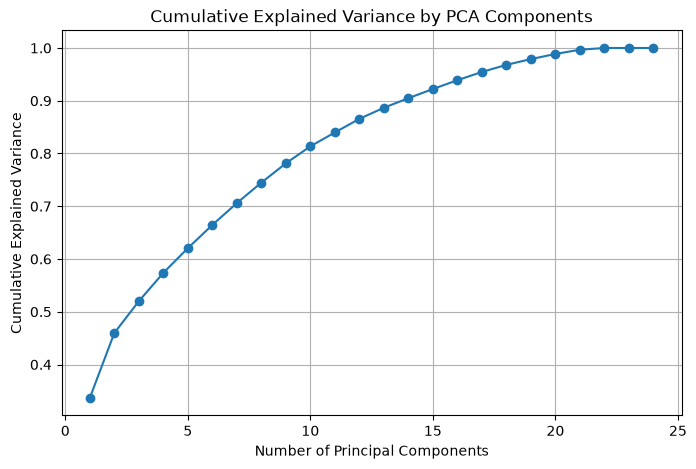

In [706]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1),cumulative_variance,marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid()
plt.show()

In [707]:
# Apply PCA with all 25 components
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)
# Convert PCA output into a DataFrame
df_pca = pd.DataFrame(df_pca,columns=[f'PC{i}' for i in range(1, 4)],index=df.index)
df_pca.head()

,PC1,PC2,PC3
0,5.011328,-0.560406,2.378525
1,-3.063273,0.016559,-0.180773
2,2.683675,-0.608521,-0.481250
3,-2.652024,-1.329340,-0.376352
4,-0.504781,0.430865,-0.597713


In [708]:
print("Explained Variance:",pca.explained_variance_ratio_.sum())

Explained Variance: 0.5199959606238496


In [711]:
best_k =2
final_kmeans = KMeans(n_clusters=best_k,random_state=42,n_init=10)
cluster_labels = final_kmeans.fit_predict(df_pca)

In [712]:
df_pca_clustered = df_pca.copy()
df_pca_clustered["Cluster"] = cluster_labels
df_pca_clustered["Cluster"].head()

0    0
1    1
2    0
3    1
4    1
Name: Cluster, dtype: int32

In [713]:
print(silhouette_df.iloc[0,])
df_pca_clustered["Cluster"].value_counts().sort_index()

K                   2.000000
Silhouette_Score    0.437078
Name: 0, dtype: float64


Cluster
0     889
1    1327
Name: count, dtype: int64

## GMM

In [727]:
bic_scores = []
aic_scores = []
# Try different number of Gaussian components
for k in range(1, 11):
    gmm = GaussianMixture(n_components=k,random_state=42, covariance_type="tied")
    gmm.fit(df_pca)
    bic_scores.append(gmm.bic(df_pca))
    aic_scores.append(gmm.aic(df_pca))

# Create comparison DataFrame
gmm_scores = pd.DataFrame({"K": range(1, 11),"BIC": bic_scores,"AIC": aic_scores})
gmm_scores

,K,BIC,AIC
0,1,26787.037330,26735.706198
1,2,26214.794886,26140.649919
2,3,25471.325937,25374.367133
3,4,25303.580391,25183.807751
4,5,25204.594423,25062.007947
5,6,25137.828106,24972.427794
6,7,24841.060179,24652.846030
7,8,24724.912264,24513.884279
8,9,24697.445090,24463.603269
9,10,24668.044159,24411.388502


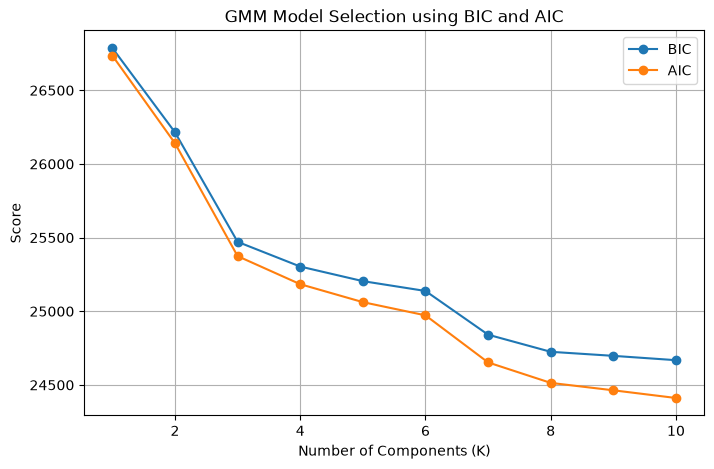

In [728]:
plt.figure(figsize=(8, 5))
plt.plot(gmm_scores["K"],gmm_scores["BIC"],marker="o",label="BIC")
plt.plot(gmm_scores["K"],gmm_scores["AIC"],marker="o",label="AIC")

plt.xlabel("Number of Components (K)")
plt.ylabel("Score")
plt.title("GMM Model Selection using BIC and AIC")

plt.legend()
plt.grid()
plt.show()

In [731]:
silhouette_scores = []
for k in range(2, 11):
    # GMM model
    gmm = GaussianMixture(n_components=k,random_state=42, covariance_type="tied")
    # Fit GMM and get cluster labels
    labels = gmm.fit_predict(df_pca)
    # Calculate Silhouette Score
    score = silhouette_score(df_pca, labels)
    silhouette_scores.append(score)

# Create DataFrame
gmm_silhouette_df = pd.DataFrame({"K": range(2, 11),"Silhouette_Score": silhouette_scores})
# Highest score first
gmm_silhouette_df = gmm_silhouette_df.sort_values(by="Silhouette_Score",ascending=False).reset_index(drop=True)
gmm_silhouette_df

,K,Silhouette_Score
0,2,0.435375
1,3,0.414461
2,4,0.354164
3,5,0.323283
4,10,0.314469
5,8,0.311521
6,7,0.307847
7,6,0.306030
8,9,0.299307


In [736]:
def plot_gmm_3d(df_pca, k):
    model = GaussianMixture(n_components=k,random_state=42,n_init=10)
    labels = model.fit_predict(df_pca)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    for cluster in range(k):
        ax.scatter(
            df_pca.iloc[labels == cluster, 0],
            df_pca.iloc[labels == cluster, 1],
            df_pca.iloc[labels == cluster, 2],
            label=f"Cluster {cluster}"
        )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(f"GMM Clustering (K={k})")
    ax.legend()

    plt.show()

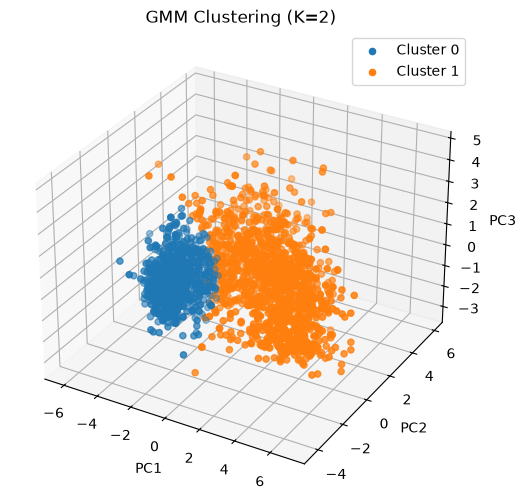

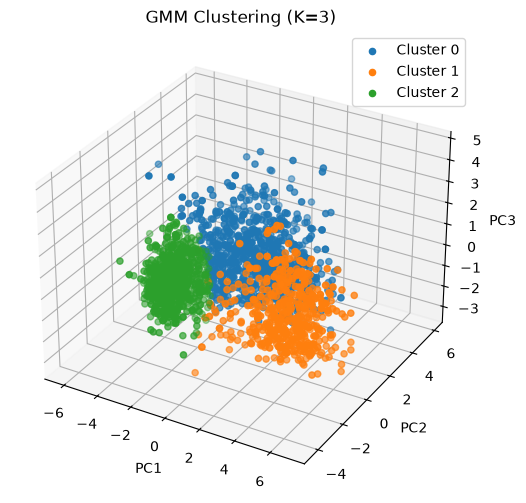

In [737]:
plot_gmm_3d(df_pca, 2)
plot_gmm_3d(df_pca, 3)

## KMEANS

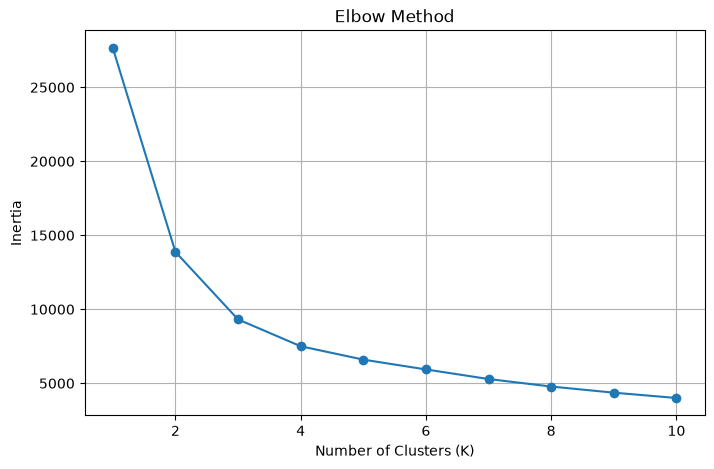

In [724]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)
# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1,11),inertia,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid()
plt.show()

In [726]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = kmeans.fit_predict(df_pca)
    score = silhouette_score(df_pca, labels)
    silhouette_scores.append(score)

# Create DataFrame
silhouette_df = pd.DataFrame({"K": range(2, 11),"Silhouette_Score": silhouette_scores})

# Sort from highest to lowest
silhouette_df = silhouette_df.sort_values(by="Silhouette_Score",ascending=False).reset_index(drop=True)
silhouette_df

,K,Silhouette_Score
0,2,0.437078
1,3,0.419739
2,4,0.361888
3,5,0.331237
4,10,0.329045
5,8,0.320080
6,9,0.312385
7,7,0.311505
8,6,0.305885


In [734]:
def plot_kmeans_3d(df_pca, k):
    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = model.fit_predict(df_pca)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    for cluster in range(k):
        ax.scatter(
            df_pca.iloc[labels == cluster, 0],
            df_pca.iloc[labels == cluster, 1],
            df_pca.iloc[labels == cluster, 2],
            label=f"Cluster {cluster}"
        )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(f"K-Means Clustering (K={k})")
    ax.legend()

    plt.show()

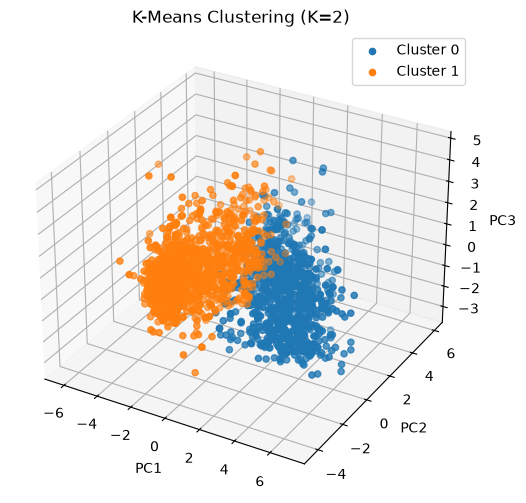

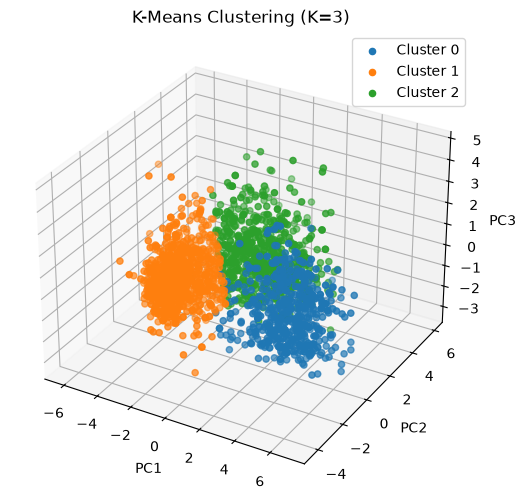

In [735]:
plot_kmeans_3d(df_pca, 2)
plot_kmeans_3d(df_pca, 3)

## KMEANS WITH COSINE DISTANCE

In [717]:
# ============================================================
# 1. COSINE K-MEANS FUNCTION
# ============================================================

def cosine_kmeans(X, n_clusters, max_iter=300, tol=1e-4):
    np.random.seed(42)
    # Randomly initialize cluster centroids
    centroids = X[np.random.choice(range(X.shape[0]),n_clusters,replace=False)]
    for _ in range(max_iter):
        # Calculate cosine distance between observations
        # and centroids
        distances = cosine_distances(X, centroids)
        # Assign each observation to nearest centroid
        labels = np.argmin(distances, axis=1)
        # Calculate new centroids
        new_centroids = np.array([X[labels == j].mean(axis=0)for j in range(n_clusters)])
        # Check convergence
        if np.all(np.abs(new_centroids - centroids) < tol):
            break
        centroids = new_centroids
    return labels, centroids
# ============================================================
# 2. COSINE K-MEANS — 2 CLUSTERS
# ============================================================
labels_2, centroids_2 = cosine_kmeans(df_pca.values,n_clusters=2)
silhouette_2 = silhouette_score(df_pca,labels_2,metric='cosine')

print("Silhouette Score for 2 clusters:", silhouette_2)
# ============================================================
# 3. COSINE K-MEANS — 3 CLUSTERS
# ============================================================

labels_3, centroids_3 = cosine_kmeans(df_pca.values,n_clusters=3)

silhouette_3 = silhouette_score(df_pca,labels_3,metric='cosine')

print("Silhouette Score for 3 clusters:", silhouette_3)

Silhouette Score for 2 clusters: 0.6435641446881388
Silhouette Score for 3 clusters: 0.6367224669654915


In [738]:
def plot_cosine_kmeans_3d(df_pca, k):
    labels, centroids = cosine_kmeans(df_pca.values,n_clusters=k)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    for cluster in range(k):
        ax.scatter(
            df_pca.iloc[labels == cluster, 0],
            df_pca.iloc[labels == cluster, 1],
            df_pca.iloc[labels == cluster, 2],
            label=f"Cluster {cluster}"
        )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(f"Cosine K-Means Clustering (K={k})")
    ax.legend()

    plt.show()

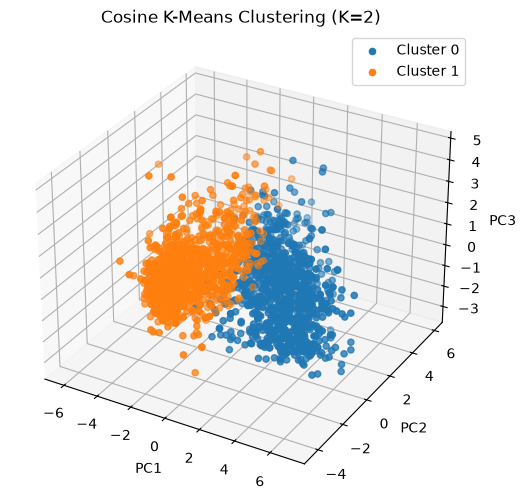

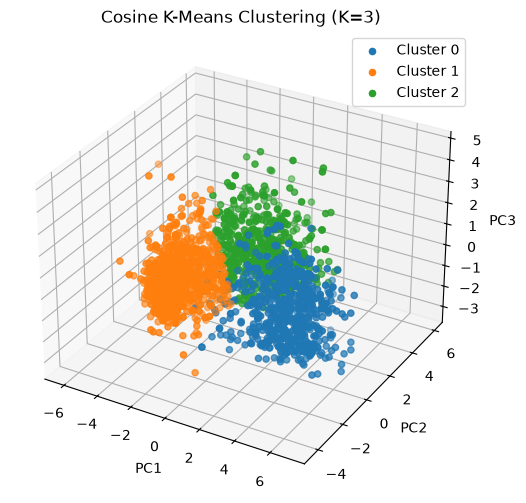

In [739]:
plot_cosine_kmeans_3d(df_pca, 2)
plot_cosine_kmeans_3d(df_pca, 3)

### Clustering Model — Key Findings
- GMM: K=2 gives the highest Silhouette Score of 0.436, slightly better than K=3 (0.411).
- Standard K-Means: K=2 gives a Silhouette Score of 0.437, with a small decline for K=3 (0.420).
- Cosine K-Means: performs substantially better, with 0.644 for K=2 and 0.637 for K=3.
- Across all three approaches, K=2 consistently performs better than K=3 based on Silhouette Score.
- Cosine K-Means with K=2 gives the strongest cluster separation and is therefore the best-performing approach among the tested models.